# Unemployment Analysis in India using Python

## Objective
The objective of this project is to analyze unemployment trends across different states and regions in India using Python. The analysis focuses on identifying regional and monthly unemployment patterns and comparing unemployment rates before and after the COVID-19 pandemic.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset
- Unemployment in India (Kaggle)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset

df = pd.read_csv("Unemployment in India.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display first five rows

df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# Check the number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (768, 7)


In [5]:
# Display all column names

print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [7]:
# Remove extra spaces from column names

df.columns = df.columns.str.strip()

# Display cleaned column names
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [8]:
# Check missing values

print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [9]:
# Remove rows with missing values

df = df.dropna()

print("Missing values removed successfully!")

Missing values removed successfully!


In [10]:
# Check again

print(df.isnull().sum())# Check again

print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [11]:
# Convert Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print(df.dtypes)

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object


In [12]:
# Create Month column

df["Month"] = df["Date"].dt.month_name()

# Display first few rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September


In [13]:
# Calculate average unemployment rate by region

region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

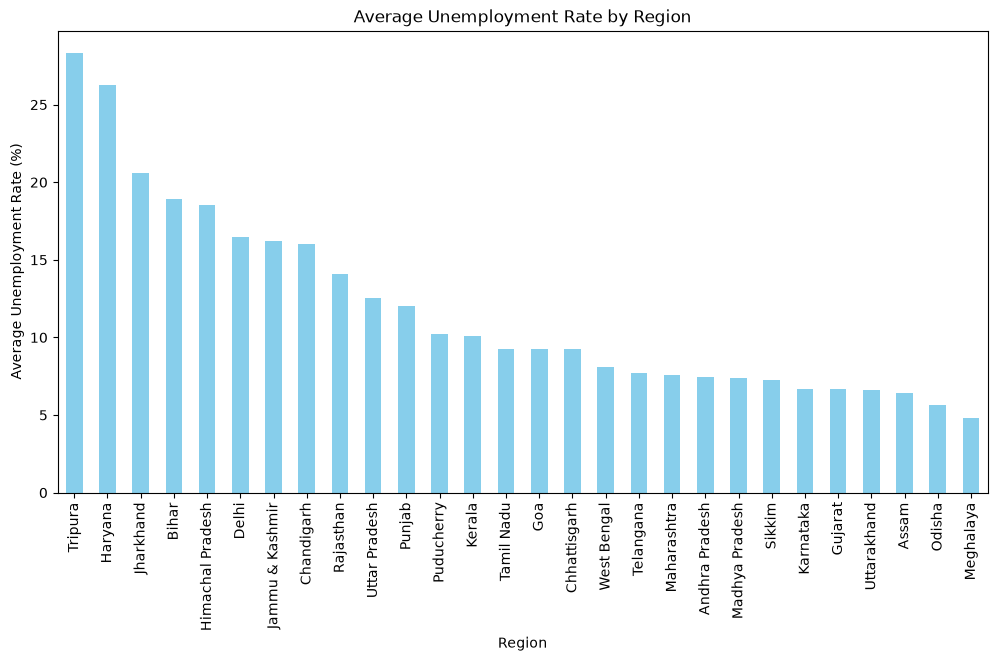

In [14]:
# Region-wise Average Unemployment Rate

plt.figure(figsize=(12,6))

region_avg.plot(kind="bar", color="skyblue")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.show()

## Observation

- The chart shows the average unemployment rate across different regions of India.
- Some regions consistently experienced higher unemployment than others.
- This comparison helps identify states/regions that may require greater employment support and policy intervention.

In [15]:
# Calculate average unemployment rate by month

monthly_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

monthly_avg

Month
April        23.641569
August        9.637925
December      9.497358
February      9.964717
January       9.950755
July          9.033889
June         10.553462
March        10.700577
May          16.646190
November      9.868364
October       9.900909
September     9.051731
Name: Estimated Unemployment Rate (%), dtype: float64

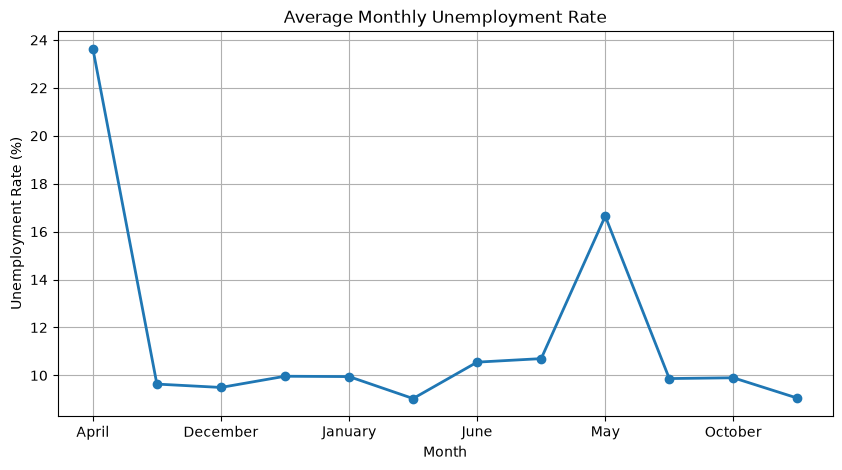

In [16]:
plt.figure(figsize=(10,5))

monthly_avg.plot(marker='o', linewidth=2)

plt.title("Average Monthly Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)

plt.show()

## Observation

- The unemployment rate changes across different months.
- Some months show noticeable increases, indicating seasonal or economic effects.
- Monthly trend analysis helps identify periods with higher unemployment.

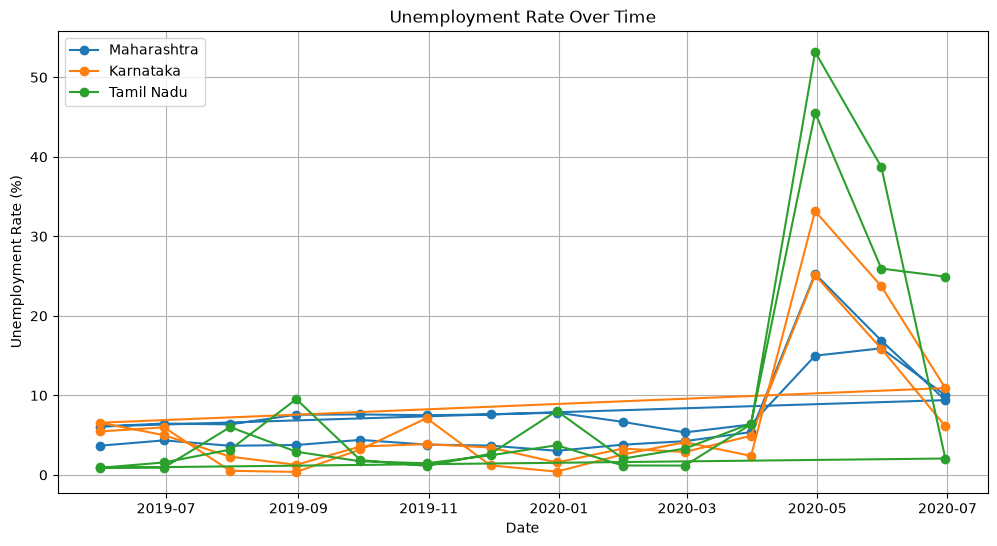

In [17]:
# Select three major states

states = ["Maharashtra", "Karnataka", "Tamil Nadu"]

plt.figure(figsize=(12,6))

for state in states:
    state_data = df[df["Region"] == state]
    plt.plot(
        state_data["Date"],
        state_data["Estimated Unemployment Rate (%)"],
        marker='o',
        label=state
    )

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
## Observation

- The unemployment rate varies across the selected states over time.
- A noticeable increase is observed during the COVID-19 period.
- Comparing multiple states helps understand regional differences in unemployment trends.

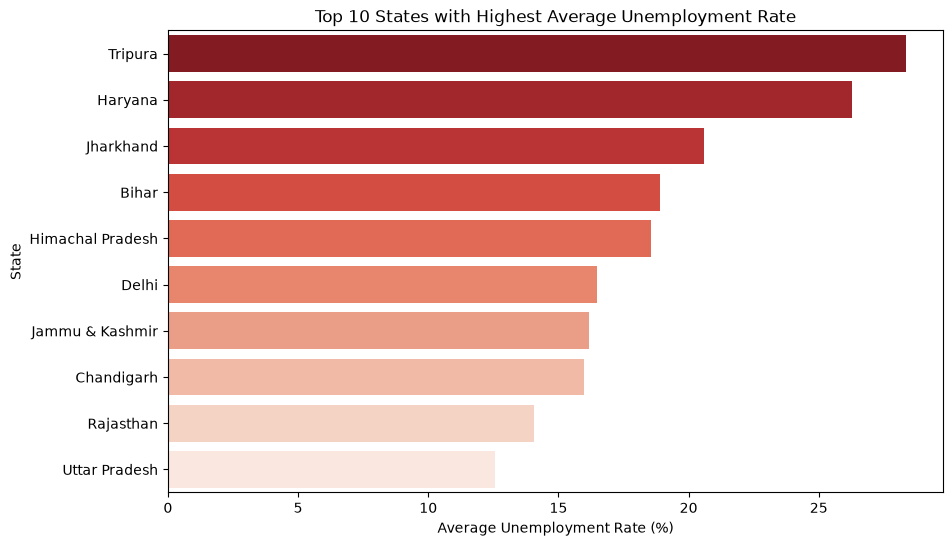

In [18]:
# Top 10 states by average unemployment rate

top10 = df.groupby("Region")["Estimated Unemployment Rate (%)"] \
          .mean() \
          .sort_values(ascending=False) \
          .head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    legend=False,
    palette="Reds_r"
)

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

## Observation

- The chart displays the ten states with the highest average unemployment rate.
- These states consistently experienced higher unemployment compared to others.
- Such analysis can help identify regions that may require targeted employment initiatives.

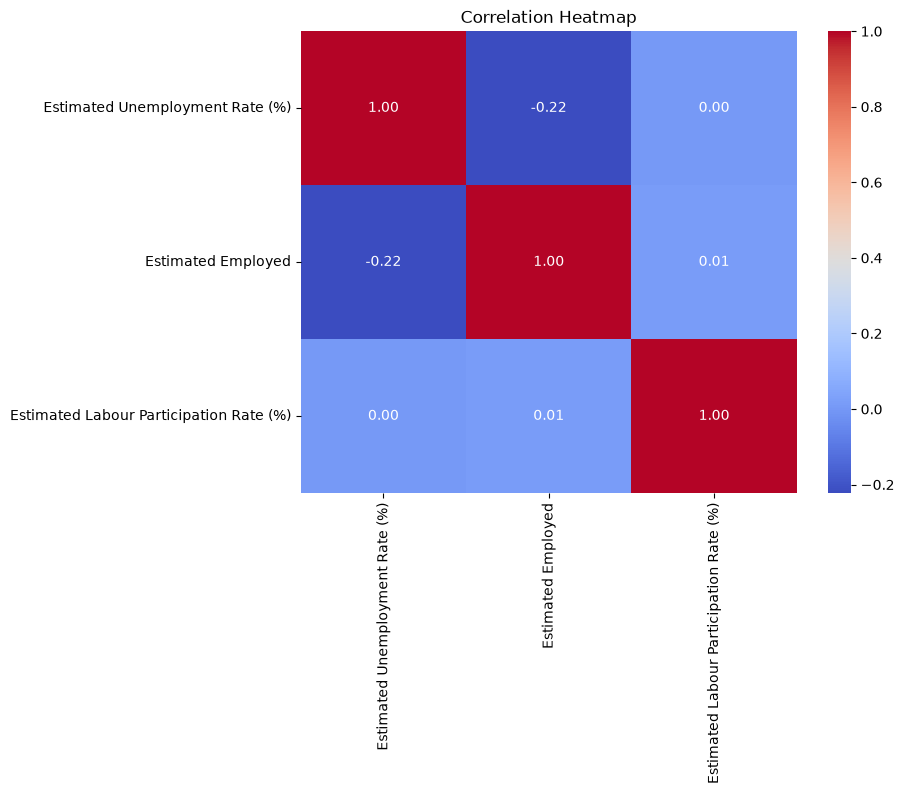

In [19]:
# Select numerical columns

corr = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

- The heatmap shows the correlation among unemployment rate, employment, and labour participation rate.
- Positive values indicate a direct relationship, while negative values indicate an inverse relationship.
- This helps understand how employment-related variables are connected.

In [20]:
# Split the data into Pre-COVID and Post-COVID periods

pre_covid = df[df["Date"] < "2020-03-01"]

post_covid = df[df["Date"] >= "2020-03-01"]

In [21]:
# Calculate average unemployment rate

pre_rate = pre_covid["Estimated Unemployment Rate (%)"].mean()
post_rate = post_covid["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate")
print("--------------------------")
print(f"Pre-COVID : {pre_rate:.2f}%")
print(f"Post-COVID: {post_rate:.2f}%")

Average Unemployment Rate
--------------------------
Pre-COVID : 9.51%
Post-COVID: 17.77%


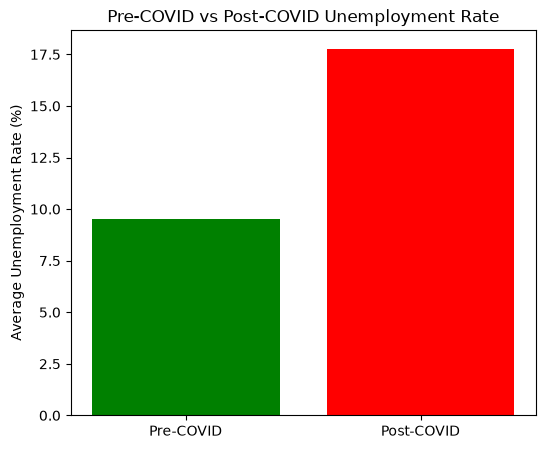

In [22]:
# Compare Pre-COVID and Post-COVID unemployment rates

plt.figure(figsize=(6,5))

plt.bar(
    ["Pre-COVID", "Post-COVID"],
    [pre_rate, post_rate],
    color=["green", "red"]
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

## Observation

- The average unemployment rate increased significantly after the COVID-19 outbreak.
- The pandemic had a major impact on employment across India.
- This comparison clearly highlights the economic effect of COVID-19 on the labour market.

# Conclusion

This project analyzed unemployment trends across India using Python.

### Key Findings

- Regional unemployment rates vary significantly across states.
- Monthly trends indicate fluctuations in unemployment throughout the year.
- The time-series analysis showed noticeable increases during the COVID-19 period.
- Some states consistently experienced higher unemployment than others.
- The correlation analysis provided insights into the relationship between unemployment, employment, and labour participation.
- The comparison between Pre-COVID and Post-COVID periods confirmed that unemployment increased significantly after the pandemic.

### Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook